<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [29]</a>'.</span>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import time
import tensorflow as tf
import tensorflow.python.keras
import matplotlib.pyplot as plt


2025-11-05 03:14:51.242736: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762312491.265413  554030 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762312491.272161  554030 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-05 03:14:51.296170: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from tensorflow.keras.applications.inception_v3 import InceptionV3 # InceptionV3
from tensorflow import keras
from tensorflow.keras.layers import Flatten, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model
from glob import glob

In [3]:
IMAGE_SIZE = [224,224]

In [4]:
# Create InceptionV3 Layer
inception = InceptionV3(include_top=False,weights='imagenet',input_shape=IMAGE_SIZE + [3])
for layer in inception.layers:
  layer.trainable = False

W0000 00:00:1762312493.633286  554030 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



       0/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step


   40960/87910968 ━━━━━━━━━━━━━━━━━━━━ 1:53 1us/step


   49152/87910968 ━━━━━━━━━━━━━━━━━━━━ 6:24 4us/step


   81920/87910968 ━━━━━━━━━━━━━━━━━━━━ 7:10 5us/step

...


85049344/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


85803008/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


86523904/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


87293952/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [5]:
# we will use the glob to see how many outputs / labels there are
folders = glob('./plantvillage/*')

In [6]:
folders

['./plantvillage/Tomato___Bacterial_spot',
 './plantvillage/Tomato___Leaf_Mold',
 './plantvillage/Tomato___Septoria_leaf_spot',
 './plantvillage/Tomato___Spider_mites Two-spotted_spider_mite',
 './plantvillage/Tomato___Early_blight',
 './plantvillage/Tomato___Tomato_mosaic_virus',
 './plantvillage/Tomato___healthy',
 './plantvillage/Tomato___Late_blight',
 './plantvillage/Tomato___Target_Spot',
 './plantvillage/Tomato___Tomato_Yellow_Leaf_Curl_Virus']

In [7]:
# Add Flatten and Dense in last layers
x = GlobalAveragePooling2D()(inception.output)
x = Dropout(0.5)(x)
prediction = Dense(len(folders),activation='softmax')(x)

In [8]:
model = Model(inputs=inception.input,outputs = prediction)
plot_model(model)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 21,823,274 (83.25 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [10]:
# Compile the model that we have created with adam and the loss is categorical_crossentropy because the classification is more than 2 classes
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [11]:
# Then use the CustomImageDataGenerator instead of ImageDataGenerator
train_datagen = ImageDataGenerator(
    validation_split=0.2,
    rescale=1./255,
    rotation_range=10,           # Very small rotations
    width_shift_range=0.05,      # Minimal shifts
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.1,              # Small zoom
    horizontal_flip=True,
    fill_mode='nearest'
)


val_datagen = ImageDataGenerator(validation_split=0.2, rescale=1./255)
test_datagen = ImageDataGenerator(validation_split=0.2, rescale=1./255)

In [12]:
# Load training and validation data using tf.data.Dataset
training_set = train_datagen.flow_from_directory(
    './plantvillage/',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',  # Make sure this is set to categorical
    subset='training',
    shuffle = True
)

val_set = val_datagen.flow_from_directory(
    './plantvillage/',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',  # Make sure this is set to categorical
    subset='validation'
)

test_dataset = test_datagen.flow_from_directory(
    './plantvillage/', 
    target_size=(224, 224),
    batch_size = 8,
    class_mode = 'categorical',
    shuffle = False

)


Found 10288 images belonging to 10 classes.


Found 2567 images belonging to 10 classes.


Found 12855 images belonging to 10 classes.


In [13]:
print(training_set)
print(val_set)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

In [15]:
tic = time.perf_counter()
history = model.fit(training_set,
                    steps_per_epoch=len(training_set),
                    validation_data=val_set,
                    validation_steps=len(val_set),
                    epochs=20, callbacks=[early_stopping, reduce_lr])
# time
toc = time.perf_counter()
model.save('Inception_V3test.keras')


Epoch 1/20


/srv/conda/envs/datpham/emotion/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



   1/1286 ━━━━━━━━━━━━━━━━━━━━ 2:13:12 6s/step - accuracy: 0.1250 - loss: 3.3749


   2/1286 ━━━━━━━━━━━━━━━━━━━━ 3:47 177ms/step - accuracy: 0.1562 - loss: 3.1124


   3/1286 ━━━━━━━━━━━━━━━━━━━━ 3:34 167ms/step - accuracy: 0.1458 - loss: 2.9918

...


1285/1286 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.7843 - loss: 0.7178


1286/1286 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.7843 - loss: 0.7178


1286/1286 ━━━━━━━━━━━━━━━━━━━━ 390s 303ms/step - accuracy: 0.7843 - loss: 0.7178 - val_accuracy: 0.8263 - val_loss: 0.5455 - learning_rate: 0.0010


Epoch 20/20



1286/1286 ━━━━━━━━━━━━━━━━━━━━ 0s 40us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - learning_rate: 2.0000e-04


In [16]:
print("Total Time:{}".format(round((toc-tic)/60,2)))

Total Time:54.4


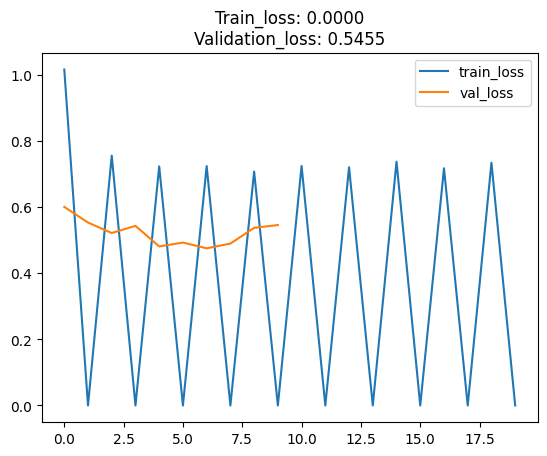

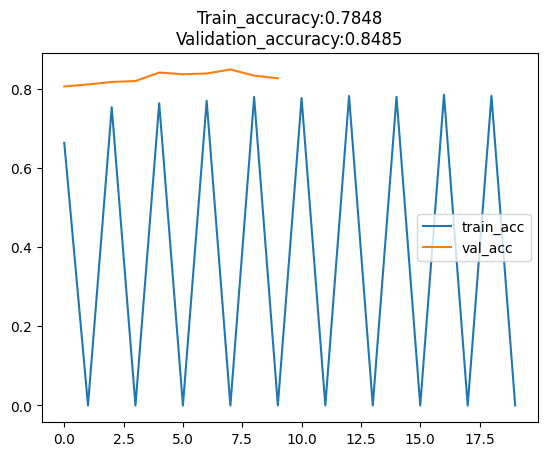

In [17]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(loss, label='train_loss')
plt.plot(val_loss,label = 'val_loss')
plt.legend()
plt.title("Train_loss: {:.4f}".format(history.history['loss'][-1]) +
          "\nValidation_loss: {:.4f}".format(history.history['val_loss'][-1]))
plt.savefig('inceptionv3_loss.png', dpi=150, bbox_inches='tight')
plt.show()

plt.plot(acc, label='train_acc')
plt.plot(val_acc,label = 'val_acc')
plt.title("Train_accuracy:{:.4f}".format(max(history.history['accuracy']))+
         "\nValidation_accuracy:{:.4f}".format(max(history.history['val_accuracy'])))
plt.legend()
plt.savefig('inceptionv3_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
scores = model.evaluate(test_dataset)


   1/1607 ━━━━━━━━━━━━━━━━━━━━ 7:04 264ms/step - accuracy: 0.0000e+00 - loss: 5.2298


   2/1607 ━━━━━━━━━━━━━━━━━━━━ 5:46 216ms/step - accuracy: 0.0938 - loss: 4.3878    


   3/1607 ━━━━━━━━━━━━━━━━━━━━ 5:58 224ms/step - accuracy: 0.1319 - loss: 3.9594


   4/1607 ━━━━━━━━━━━━━━━━━━━━ 5:49 218ms/step - accuracy: 0.1615 - loss: 3.6665


   5/1607 ━━━━━━━━━━━━━━━━━━━━ 5:52 220ms/step - accuracy: 0.2092 - loss: 3.3873

...


1604/1607 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.7901 - loss: 0.6238


1605/1607 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.7901 - loss: 0.6237


1606/1607 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.7902 - loss: 0.6236


1607/1607 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.7902 - loss: 0.6235


1607/1607 ━━━━━━━━━━━━━━━━━━━━ 288s 179ms/step - accuracy: 0.7903 - loss: 0.6234


In [19]:
y_pred = model.predict(test_dataset)    


   1/1607 ━━━━━━━━━━━━━━━━━━━━ 46:42 2s/step


   2/1607 ━━━━━━━━━━━━━━━━━━━━ 4:14 158ms/step


   3/1607 ━━━━━━━━━━━━━━━━━━━━ 3:59 149ms/step


   4/1607 ━━━━━━━━━━━━━━━━━━━━ 4:03 152ms/step


   5/1607 ━━━━━━━━━━━━━━━━━━━━ 4:02 151ms/step

...


1604/1607 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


1605/1607 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


1606/1607 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


1607/1607 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


1607/1607 ━━━━━━━━━━━━━━━━━━━━ 246s 152ms/step


In [20]:
y_predict = np.argmax(y_pred,axis=1)
y_predict

array([4, 4, 4, ..., 9, 9, 9])

In [21]:
y_true = test_dataset.classes
y_true

array([0, 0, 0, ..., 9, 9, 9], dtype=int32)

In [22]:
from sklearn.metrics import classification_report, confusion_matrix

In [23]:
class_name = ['Tomato_Bacterial_spot','Tomato_Early_blight','Tomato_Late_blight','Tomato_Leaf_Mold','Tomato_Septoria_leaf_spot','Tomato_Spider_mites_Two_spotted_spider_mite','Tomato__Target_Spot','Tomato__Tomato_YellowLeaf__Curl_Virus','Tomato__Tomato_mosaic_virus','Tomato_healthy']

In [24]:
print(classification_report(y_true,y_predict,target_names = class_name))

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       1.00      0.18      0.30        28
                        Tomato_Early_blight       0.62      0.79      0.69       800
                         Tomato_Late_blight       0.93      0.78      0.85      1527
                           Tomato_Leaf_Mold       0.89      0.71      0.79       761
                  Tomato_Septoria_leaf_spot       0.79      0.84      0.82      1417
Tomato_Spider_mites_Two_spotted_spider_mite       0.86      0.76      0.81      1341
                        Tomato__Target_Spot       0.79      0.68      0.73      1123
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.89      0.99      0.94      4286
                Tomato__Tomato_mosaic_virus       0.84      0.78      0.81       299
                             Tomato_healthy       0.91      0.89      0.90      1273

                                   accuracy                    

In [25]:
import seaborn as sns

In [26]:
cm = confusion_matrix(y_true,y_predict)
cm

array([[   5,    2,    1,    0,   12,    0,    5,    3,    0,    0],
       [   0,  630,   22,    8,   58,   18,   26,   28,    6,    4],
       [   0,  171, 1194,   19,   41,    9,   24,   52,    0,   17],
       [   0,   45,   21,  537,   50,   17,    5,   71,   12,    3],
       [   0,   82,   24,   15, 1190,    9,   30,   53,    8,    6],
       [   0,   17,    3,    6,   35, 1019,   59,  156,   10,   36],
       [   0,   44,   12,    4,   78,   66,  766,  102,    2,   49],
       [   0,   14,    0,    1,   14,    8,    0, 4248,    1,    0],
       [   0,    5,    3,   14,   14,    2,    0,   29,  232,    0],
       [   0,    8,    6,    0,    9,   40,   52,   19,    4, 1135]])

In [27]:
cm_normalized = np.round(cm/np.sum(cm,axis=1).reshape(-1,1),2)
print(cm_normalized)

[[0.18 0.07 0.04 0.   0.43 0.   0.18 0.11 0.   0.  ]
 [0.   0.79 0.03 0.01 0.07 0.02 0.03 0.04 0.01 0.  ]
 [0.   0.11 0.78 0.01 0.03 0.01 0.02 0.03 0.   0.01]
 [0.   0.06 0.03 0.71 0.07 0.02 0.01 0.09 0.02 0.  ]
 [0.   0.06 0.02 0.01 0.84 0.01 0.02 0.04 0.01 0.  ]
 [0.   0.01 0.   0.   0.03 0.76 0.04 0.12 0.01 0.03]
 [0.   0.04 0.01 0.   0.07 0.06 0.68 0.09 0.   0.04]
 [0.   0.   0.   0.   0.   0.   0.   0.99 0.   0.  ]
 [0.   0.02 0.01 0.05 0.05 0.01 0.   0.1  0.78 0.  ]
 [0.   0.01 0.   0.   0.01 0.03 0.04 0.01 0.   0.89]]


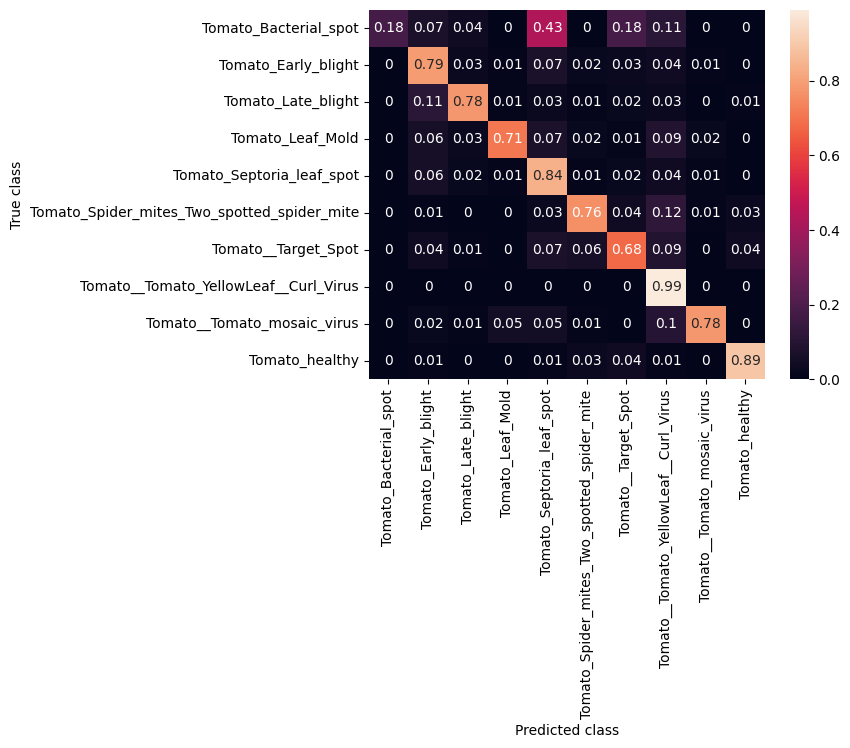

In [28]:
sns.heatmap(cm_normalized, annot=True,xticklabels=class_name, yticklabels=class_name,)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.savefig('inceptionv3_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [1]:
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

Epochs = [i+1 for i in range(len(tr_acc))]

plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

NameError: name 'history' is not defined

In [ ]:
import pickle
# Save the history object to a file
with open('history_inceptionv3.pkl', 'wb') as file:
    pickle.dump(history.history, file)